In [1]:
# Import packages
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
import os

In [2]:
# Change directory to the data location
os.chdir('../../ml_data')


In [3]:
df = pd.read_csv('fraud_data_cleaned.csv')

In [4]:
df

,TransactionType,IsFraud,Year,Month,Day,hour,un_amount,standardised_amount,per_100k,FraudCount
0,1,0,2024,3,19,13,0,0.112740,8.0,1
1,0,0,2024,1,8,10,1,-1.187655,1.0,1
2,0,0,2024,7,12,18,1,-1.475318,6.0,1
3,1,0,2024,1,2,11,1,-0.714213,6.0,1
4,0,0,2024,5,12,12,1,-1.095303,1.0,2
...,...,...,...,...,...,...,...,...,...,...
63401,1,0,2024,1,12,17,0,0.268187,1.0,1
63402,0,0,2024,5,25,6,1,0.864416,3.0,2
63403,1,0,2024,4,20,15,1,-1.305499,6.0,1
63404,0,0,2024,10,18,9,1,0.869165,6.0,2


In [5]:
# Test train split
X_train, X_test, y_train, y_test = train_test_split(df.drop('IsFraud', axis=1),df['IsFraud'], test_size=0.25, random_state=42)

In [6]:
pen_var = None
tol_var = 1e-4
dual_var = False
c_var = 1.0
fit_intercept_var = False
intercept_scaling_var = 1
class_weight_var = 'balanced'
random_state_var = 42
sol_var = 'saga'
max_iter_var = 10000
multi_class_var = 'auto'
verbose_var = 0
warm_start_var = False
n_jobs_var = None
l1_ratio_var = None


# Train the model
LogReg = LogisticRegression(penalty = pen_var, 
                            tol = tol_var,
                            dual=dual_var,
                            C = c_var,
                            fit_intercept = fit_intercept_var, 
                            intercept_scaling = intercept_scaling_var,
                            class_weight = class_weight_var,
                            random_state= random_state_var,
                            solver=sol_var,
                            max_iter=max_iter_var,
                            multi_class= multi_class_var,
                            verbose=verbose_var,
                            warm_start=warm_start_var,
                            n_jobs=n_jobs_var,
                            l1_ratio=l1_ratio_var
                             )
LogReg.fit(X_train, y_train)

/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,10000
,multi_class,'auto'


In [7]:
# Scoring
train_score = LogReg.score(X_train, y_train)
print(f"Training Accuracy: {round(train_score*100)}%")
test_score = LogReg.score(X_test, y_test)
print(f"Testing Accuracy: {round(test_score*100)}%")

Training Accuracy: 62%
Testing Accuracy: 62%


In [8]:
# Predictions for X_test
y_pred = LogReg.predict(X_test)

In [9]:
# F1 Score
f1_score(y_true=y_test, y_pred=y_pred, average='weighted')

0.746783741577437

In [10]:
# Recall score
recall_score(y_true=y_test, y_pred=y_pred, average='weighted')

0.6169568508705526

In [11]:
# Precision Score
precision_score(y_true=y_test, y_pred=y_pred, average='weighted')

0.9706983813979808

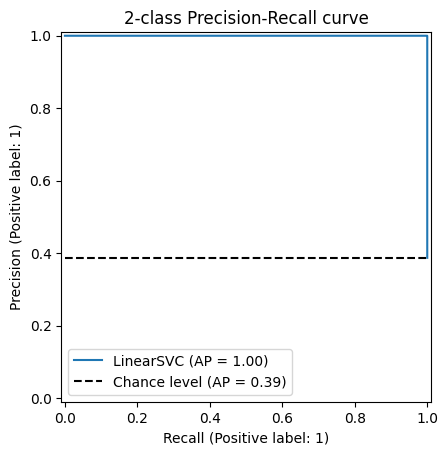

In [12]:
display = PrecisionRecallDisplay.from_estimator(
    LogReg, X_test, y_pred, name="LinearSVC", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

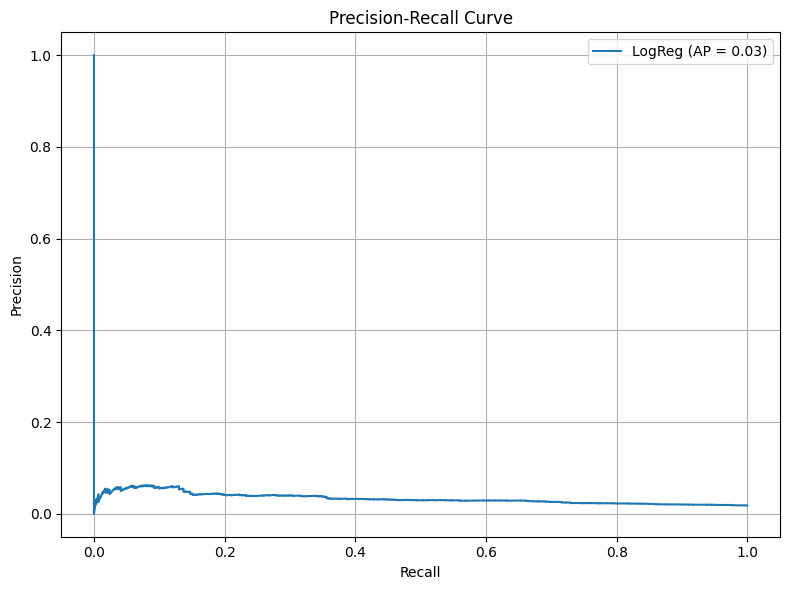

In [13]:
y_scores =  LogReg.predict_proba(X_test)[:, 1]

# Assuming you have the true labels
# (replace y_test with your actual test labels)
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'LogReg (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

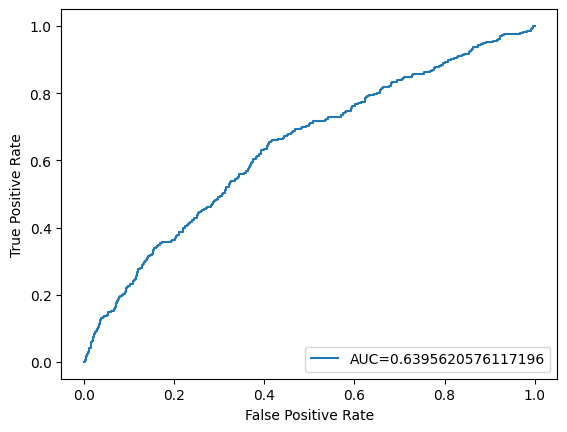

In [14]:
#define metrics
y_pred_proba = LogReg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

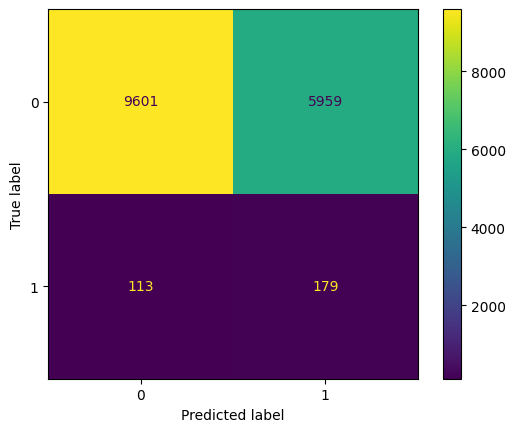

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=LogReg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,

                              display_labels=LogReg.classes_)

disp.plot()

plt.show()

In [16]:
cm

array([[9601, 5959],
       [ 113,  179]])